#1) Import the dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Green_Cities_Dataset - Sheet1.csv to Green_Cities_Dataset - Sheet1.csv


In [4]:
import pandas as pd

df = pd.read_csv("Green_Cities_Dataset - Sheet1.csv")

df.head()

,City,Country,Air_Quality_Index,Green_Cover_Percentage,Solar_Installations,EV_Charging_Stations,Public_Transport_Usage,Carbon_Emissions_Per_Capita,Sustainability_Rating
0,Ahmedabad,India,145,18,3200,250,42,1.9,Medium
1,Mumbai,India,160,15,4200,380,55,2.3,Medium
2,Delhi,India,210,12,5000,(leave blank),60,2.8,Low
3,Bengaluru,India,95,28,6100,550,48,1.5,High
4,Chennai,India,130,20,3400,300,44,1.8,Medium


#2) Understand the dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   City                         15 non-null     object 
 1   Country                      15 non-null     object 
 2   Air_Quality_Index            15 non-null     int64  
 3   Green_Cover_Percentage       15 non-null     object 
 4   Solar_Installations          15 non-null     object 
 5   EV_Charging_Stations         15 non-null     object 
 6   Public_Transport_Usage       15 non-null     int64  
 7   Carbon_Emissions_Per_Capita  15 non-null     float64
 8   Sustainability_Rating        15 non-null     object 
dtypes: float64(1), int64(2), object(6)
memory usage: 1.2+ KB


### Dataset Overview

This dataset contains sustainability indicators of various cities around the world.

Features include:
- Air Quality Index
- Green Cover Percentage
- Solar Installations
- EV Charging Stations
- Public Transport Usage
- Carbon Emissions Per Capita
- Sustainability Rating

The objective is to analyze sustainability trends and identify relationships between environmental and infrastructure indicators.

#3) Check null values

In [6]:
df.isnull().sum()

,0
City,0
Country,0
Air_Quality_Index,0
Green_Cover_Percentage,0
Solar_Installations,0
EV_Charging_Stations,0
Public_Transport_Usage,0
Carbon_Emissions_Per_Capita,0
Sustainability_Rating,0


#4) Handle null values

In [8]:
# Converting columns to numeric data type

df["Green_Cover_Percentage"] = pd.to_numeric(
    df["Green_Cover_Percentage"],
    errors="coerce"
)

df["Solar_Installations"] = pd.to_numeric(
    df["Solar_Installations"],
    errors="coerce"
)

df["EV_Charging_Stations"] = pd.to_numeric(
    df["EV_Charging_Stations"],
    errors="coerce"
)

In [9]:
# Handling missing values using mean imputation

df["Green_Cover_Percentage"].fillna(
    df["Green_Cover_Percentage"].mean(),
    inplace=True
)

df["Solar_Installations"].fillna(
    df["Solar_Installations"].mean(),
    inplace=True
)

df["EV_Charging_Stations"].fillna(
    df["EV_Charging_Stations"].mean(),
    inplace=True
)

/tmp/ipykernel_501/3368423688.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Green_Cover_Percentage"].fillna(
/tmp/ipykernel_501/3368423688.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.meth

In [10]:
# Checking remaining missing values

df.isnull().sum()

,0
City,0
Country,0
Air_Quality_Index,0
Green_Cover_Percentage,0
Solar_Installations,0
EV_Charging_Stations,0
Public_Transport_Usage,0
Carbon_Emissions_Per_Capita,0
Sustainability_Rating,0


## Missing Value Treatment

The dataset contained missing values in:

- Green_Cover_Percentage
- Solar_Installations
- EV_Charging_Stations

Since these features are numerical and only a small number of records were missing, mean imputation was used to preserve the dataset size and maintain statistical consistency.

The missing values were replaced with the average value of their respective columns.

#5) Feature Engineering

In [11]:
# Feature Engineering

df["Renewable_Infrastructure_Score"] = (
    df["Solar_Installations"] +
    df["EV_Charging_Stations"] +
    df["Public_Transport_Usage"]
)

df.head()

,City,Country,Air_Quality_Index,Green_Cover_Percentage,Solar_Installations,EV_Charging_Stations,Public_Transport_Usage,Carbon_Emissions_Per_Capita,Sustainability_Rating,Renewable_Infrastructure_Score
0,Ahmedabad,India,145,18.0,3200.0,250.000000,42,1.9,Medium,3492.000000
1,Mumbai,India,160,15.0,4200.0,380.000000,55,2.3,Medium,4635.000000
2,Delhi,India,210,12.0,5000.0,571.428571,60,2.8,Low,5631.428571
3,Bengaluru,India,95,28.0,6100.0,550.000000,48,1.5,High,6698.000000
4,Chennai,India,130,20.0,3400.0,300.000000,44,1.8,Medium,3744.000000


## Feature Engineering

A new feature called Renewable_Infrastructure_Score was created.

This feature combines:
- Solar Installations
- EV Charging Stations
- Public Transport Usage

The purpose of this feature is to represent the overall sustainability infrastructure of a city using a single metric.

Cities with higher values are expected to have better green infrastructure and environmental readiness.

#6) Seaborn Visualizations

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

##1. Distribution of Air Quality Index

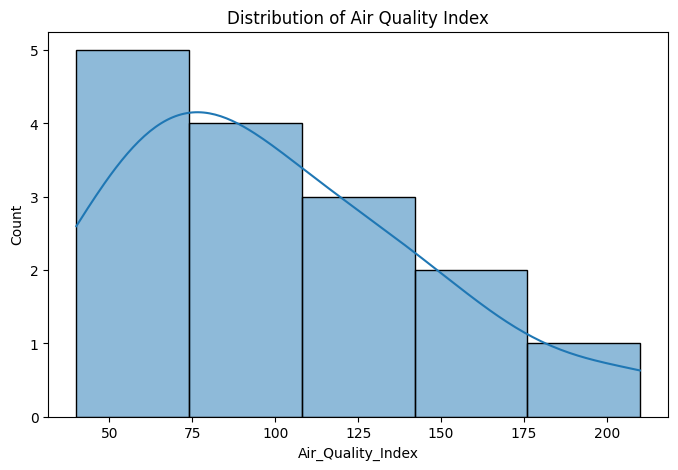

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Air_Quality_Index"], kde=True)
plt.title("Distribution of Air Quality Index")
plt.show()

##2. Carbon Emissions vs Renewable Percentage

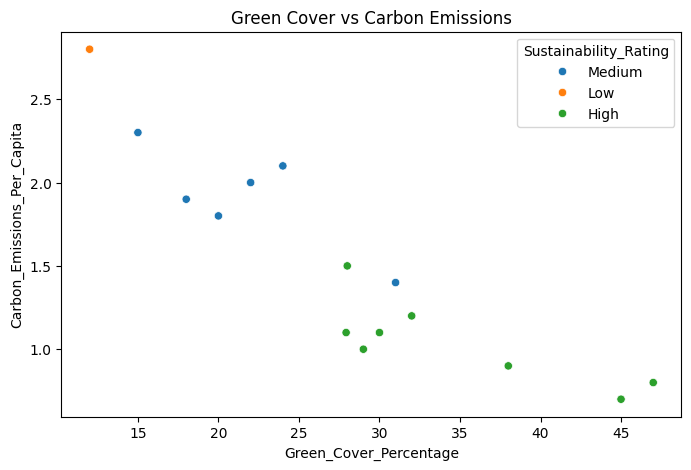

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Green_Cover_Percentage",
    y="Carbon_Emissions_Per_Capita",
    hue="Sustainability_Rating"
)

plt.title("Green Cover vs Carbon Emissions")
plt.show()

##3. Sustainability Rating Count

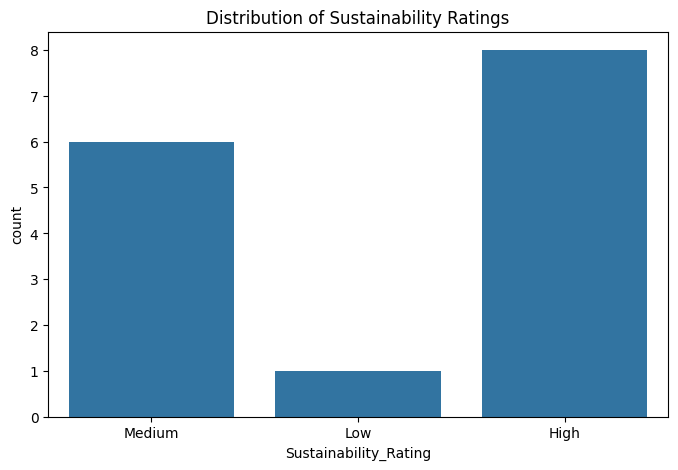

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Sustainability_Rating"
)

plt.title("Distribution of Sustainability Ratings")
plt.show()

##4. Correlation Heatmap

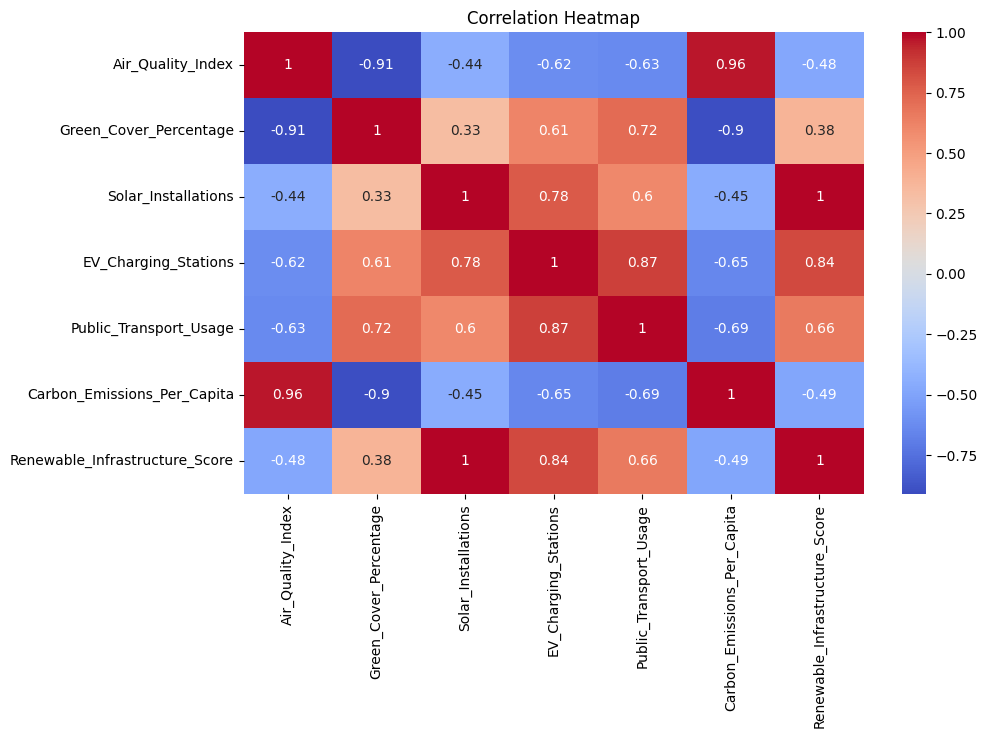

In [16]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## Visualization Insights

- Cities with better green cover generally tend to have lower carbon emissions.
- High sustainability ratings are associated with stronger renewable infrastructure.
- Air Quality Index varies significantly across cities.
- Numerical features show meaningful correlations that can help in predictive modeling.

#7) Scaling Numerical Columns

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    "Air_Quality_Index",
    "Green_Cover_Percentage",
    "Solar_Installations",
    "EV_Charging_Stations",
    "Public_Transport_Usage",
    "Carbon_Emissions_Per_Capita",
    "Renewable_Infrastructure_Score"
]

df_scaled = df.copy()

df_scaled[numerical_columns] = scaler.fit_transform(
    df_scaled[numerical_columns]
)

df_scaled.head()

,City,Country,Air_Quality_Index,Green_Cover_Percentage,Solar_Installations,EV_Charging_Stations,Public_Transport_Usage,Carbon_Emissions_Per_Capita,Sustainability_Rating,Renewable_Infrastructure_Score
0,Ahmedabad,India,1.010362,-1.020108,-1.449994,-1.545078,-1.433943,0.658653,Medium,-1.505727
1,Mumbai,India,1.342233,-1.328342,-0.689697,-0.920180,-0.428120,1.328469,Medium,-0.739832
2,Delhi,India,2.448468,-1.636577,-0.081460,0.000000,-0.041265,2.165740,Low,-0.072151
3,Bengaluru,India,-0.095874,0.007339,0.754866,-0.103005,-0.969717,-0.011164,High,0.642531
4,Chennai,India,0.678491,-0.814619,-1.297935,-1.304733,-1.279201,0.491199,Medium,-1.336868


## Feature Scaling

StandardScaler was applied to numerical columns.

Scaling transforms numerical values so that they have:
- Mean = 0
- Standard Deviation = 1

This improves the performance of many machine learning algorithms and ensures that larger numerical values do not dominate smaller ones.

#8) Encoding Categorical Variables

In [18]:
df_encoded = pd.get_dummies(
    df_scaled,
    columns=["Country"],
    drop_first=True
)

df_encoded.head()

,City,Air_Quality_Index,Green_Cover_Percentage,Solar_Installations,EV_Charging_Stations,Public_Transport_Usage,Carbon_Emissions_Per_Capita,Sustainability_Rating,Renewable_Infrastructure_Score,Country_Canada,Country_France,Country_Germany,Country_India,Country_Japan,Country_Norway,Country_Singapore,Country_South Africa,Country_UK,Country_USA
0,Ahmedabad,1.010362,-1.020108,-1.449994,-1.545078,-1.433943,0.658653,Medium,-1.505727,False,False,False,True,False,False,False,False,False,False
1,Mumbai,1.342233,-1.328342,-0.689697,-0.920180,-0.428120,1.328469,Medium,-0.739832,False,False,False,True,False,False,False,False,False,False
2,Delhi,2.448468,-1.636577,-0.081460,0.000000,-0.041265,2.165740,Low,-0.072151,False,False,False,True,False,False,False,False,False,False
3,Bengaluru,-0.095874,0.007339,0.754866,-0.103005,-0.969717,-0.011164,High,0.642531,False,False,False,True,False,False,False,False,False,False
4,Chennai,0.678491,-0.814619,-1.297935,-1.304733,-1.279201,0.491199,Medium,-1.336868,False,False,False,True,False,False,False,False,False,False


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_encoded["Sustainability_Rating"] = label_encoder.fit_transform(
    df_encoded["Sustainability_Rating"]
)

df_encoded["City"] = label_encoder.fit_transform(
    df_encoded["City"]
)

df_encoded.head()

## Encoding Categorical Variables

Two encoding techniques were used:

### 1. One-Hot Encoding using pd.get_dummies()
Applied on:
- Country

Reason:
- Countries do not have any natural order or ranking.

### 2. Label Encoding
Applied on:
- City
- Sustainability_Rating

Reason:
- Machine learning models require numerical input values.
- Label encoding converts categorical values into numerical representations.

#9) Final Insights



1. Cities with higher green cover generally exhibit lower carbon emissions.

2. Better public transport systems and larger numbers of EV charging stations contribute positively to sustainability.

3. Renewable infrastructure investment strongly influences sustainability ratings.

4. Feature engineering helped create a more meaningful representation of green infrastructure through the Renewable_Infrastructure_Score feature.

5. Missing values were handled using mean imputation to preserve information while maintaining statistical consistency.

6. Scaling was applied to ensure fair contribution of all numerical features during machine learning.

7. Categorical features were encoded because machine learning algorithms cannot directly process text values.

8. Data visualization helped identify important relationships and trends within the dataset.

# Summary

In this project, a sustainability dataset containing environmental and infrastructure indicators of various cities was analyzed.

The workflow included:

- Importing and exploring the dataset
- Understanding feature relationships
- Handling missing values
- Performing feature engineering
- Creating visualizations using Seaborn
- Scaling numerical features
- Encoding categorical variables
- Generating business insights

This preprocessing pipeline prepares the dataset for future machine learning applications and sustainability analysis.